# Open WOD datasets

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import gsw

### Plot locations

In [5]:
ctd_meta_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/CTD/*.CTD.nc').swap_dims({'casts': 'time'})
drb_meta_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/DRB/*.DRB.nc').swap_dims({'casts': 'time'})
osd_meta_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/OSD/*.OSD.nc').swap_dims({'casts': 'time'})
pfl_meta_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/PFL/*.PFL.nc').swap_dims({'casts': 'time'})
apb_meta_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/APB/*.APB.nc').swap_dims({'casts': 'time'})
gld_meta_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/raw_depths/GLD/*.GLD.nc').swap_dims({'casts': 'time'})

/Users/mzahn/miniforge3/envs/sassie/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in ct_from_t
  return func(*(_execute_task(a, cache) for a in args))
/Users/mzahn/miniforge3/envs/sassie/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in rho
  return func(*(_execute_task(a, cache) for a in args))
/Users/mzahn/miniforge3/envs/sassie/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: invalid value encountered in rho
  return func(*(_execute_task(a, cache) for a in args))
/Users/mzahn/miniforge3/envs/sassie/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in ct_from_t
  return func(*(_execute_task(a, cache) for a in args))
/Users/mzahn/miniforge3/envs/sassie/lib/python3.11/site-packages/dask/core.py:127: RuntimeWarning: overflow encountered in rho
  return func(*(_execute_task(a, cache) for a in args))
/Users/mzahn/miniforge3/envs/sassie/lib/python3.11/site-packages/das

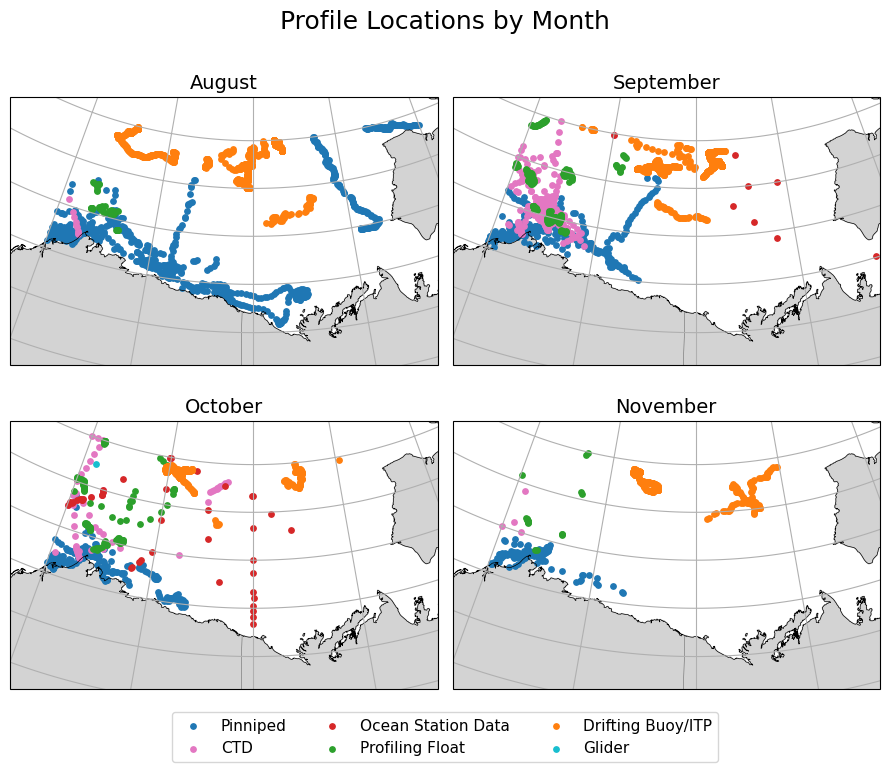

In [7]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(9, 8),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-160, -125, 67.5, 75.5], crs=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # gridlines (no labels)
    gl = ax.gridlines(draw_labels=False, dms=True,
                      x_inline=False, y_inline=False)

    # subset each dataset by month
    apb_m = apb_meta_ds.where(apb_meta_ds.time.dt.month == month, drop=True)
    ctd_m = ctd_meta_ds.where(ctd_meta_ds.time.dt.month == month, drop=True)
    osd_m = osd_meta_ds.where(osd_meta_ds.time.dt.month == month, drop=True)
    pfl_m = pfl_meta_ds.where(pfl_meta_ds.time.dt.month == month, drop=True)
    drb_m = drb_meta_ds.where(drb_meta_ds.time.dt.month == month, drop=True)
    gld_m = gld_meta_ds.where(gld_meta_ds.time.dt.month == month, drop=True)

    # scatter plots
    ax.scatter(apb_m.lon, apb_m.lat, s=15, color='tab:blue',
               transform=ccrs.PlateCarree(), label='Pinniped')

    ax.scatter(ctd_m.lon, ctd_m.lat, s=15, color='tab:pink',
               transform=ccrs.PlateCarree(), label='CTD')

    ax.scatter(osd_m.lon, osd_m.lat, s=15, color='tab:red',
               transform=ccrs.PlateCarree(), label='Ocean Station Data')

    ax.scatter(pfl_m.lon, pfl_m.lat, s=15, color='tab:green',
               transform=ccrs.PlateCarree(), label='Profiling Float')

    ax.scatter(drb_m.lon, drb_m.lat, s=15, color='tab:orange',
               transform=ccrs.PlateCarree(), label='Drifting Buoy/ITP')

    ax.scatter(gld_m.lon, gld_m.lat, s=15, color='tab:cyan',
               transform=ccrs.PlateCarree(), label='Glider')

    # title for each panel
    ax.set_title(f"{month_names[month]}", fontsize=14)

fig.suptitle("Profile Locations by Month", fontsize=18, y=0.98)

# single legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, 0.03))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

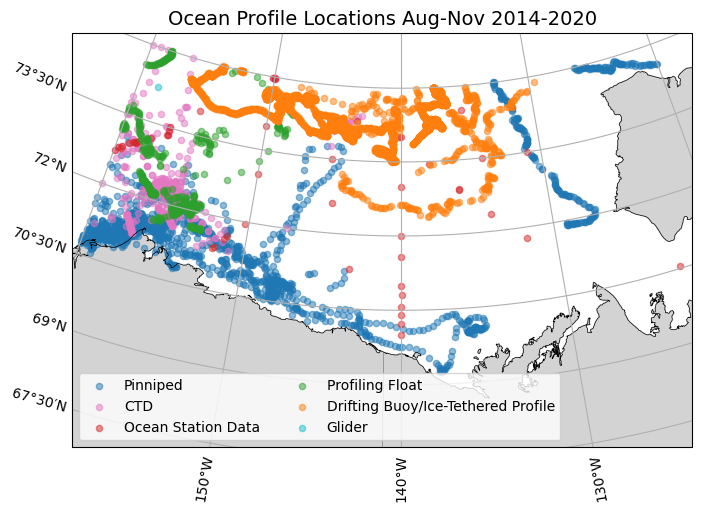

In [18]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

# create figure and axis
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Beaufort Sea extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-157, -125, 67, 75.5], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# plot CTD profile locations

ax.scatter(
    apb_meta_ds.lon,
    apb_meta_ds.lat,
    s=20,
    color='tab:blue',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Pinniped', alpha=0.5
)

ax.scatter(
    ctd_meta_ds.lon,
    ctd_meta_ds.lat,
    s=20,
    color='tab:pink',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='CTD', alpha=0.5
)

ax.scatter(
    osd_meta_ds.lon,
    osd_meta_ds.lat,
    s=20,
    color='tab:red',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Ocean Station Data', alpha=0.5
)

ax.scatter(
    pfl_meta_ds.lon,
    pfl_meta_ds.lat,
    s=20,
    color='tab:green',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Profiling Float', alpha=0.5
)

ax.scatter(
    drb_meta_ds.lon,
    drb_meta_ds.lat,
    s=20,
    color='tab:orange',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Drifting Buoy/Ice-Tethered Profile', alpha=0.5
)

ax.scatter(
    gld_meta_ds.lon,
    gld_meta_ds.lat,
    s=20,
    color='tab:cyan',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Glider', alpha=0.5
)


# add legend and title
ax.legend(loc='lower left',ncol=2)
ax.set_title('Ocean Profile Locations Aug-Nov 2014-2020', fontsize=14)

plt.show()

### Plot vars

In [22]:
# open bathymetry
bathy_ds = xr.open_dataset('/Users/mzahn/data/GEBCO/GEBCO_2023.nc')

In [24]:
bathy_beaufort = bathy_ds.elevation.sel(lat=slice(68,80,5),lon=slice(-170,-120,5))

In [26]:
ctd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/CTD/*.nc')
drb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/DRB/*.nc')
osd_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/OSD/*.nc')
pfl_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/PFL/*.nc')
apb_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/APB/*.nc')
gld_ds = xr.open_mfdataset('/Users/mzahn/data/SASSIE/WOD/standard_depths/GLD/*.nc')

In [27]:
# print out sample sizes
print(len(ctd_meta_ds.time))
print(len(drb_meta_ds.time))
print(len(osd_meta_ds.time))
print(len(pfl_meta_ds.time))
print(len(apb_meta_ds.time))
print(len(gld_meta_ds.time))

423
3052
51
402
1901
1


In [28]:
print(len(ctd_ds.time))
print(len(drb_ds.time))
print(len(osd_ds.time))
print(len(pfl_ds.time))
print(len(apb_ds.time))
print(len(gld_ds.time))

403
2019
49
314
1708
1


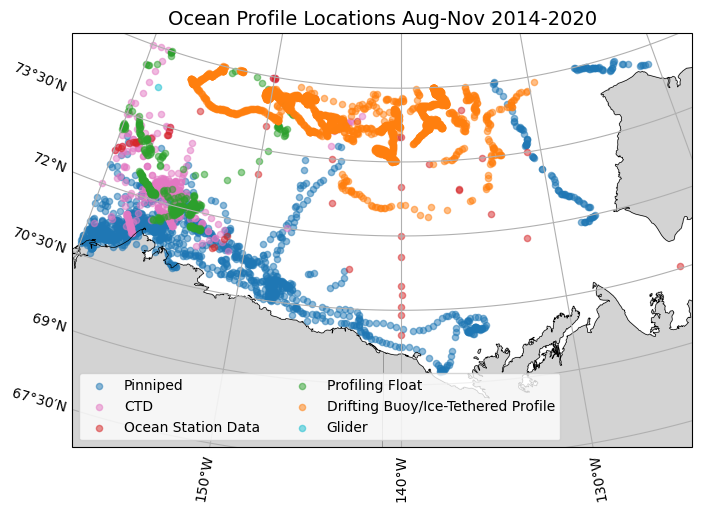

In [32]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

# create figure and axis
fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=proj)

# Beaufort Sea extent [lon_min, lon_max, lat_min, lat_max]
ax.set_extent([-157, -125, 67, 75.5], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)
gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

# plot CTD profile locations

ax.scatter(
    apb_ds.lon,
    apb_ds.lat,
    s=20,
    color='tab:blue',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Pinniped', alpha=0.5
)

ax.scatter(
    ctd_ds.lon,
    ctd_ds.lat,
    s=20,
    color='tab:pink',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='CTD', alpha=0.5
)

ax.scatter(
    osd_ds.lon,
    osd_ds.lat,
    s=20,
    color='tab:red',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Ocean Station Data', alpha=0.5
)

ax.scatter(
    pfl_ds.lon,
    pfl_ds.lat,
    s=20,
    color='tab:green',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Profiling Float', alpha=0.5
)

ax.scatter(
    drb_ds.lon,
    drb_ds.lat,
    s=20,
    color='tab:orange',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Drifting Buoy/Ice-Tethered Profile', alpha=0.5
)

ax.scatter(
    gld_ds.lon,
    gld_ds.lat,
    s=20,
    color='tab:cyan',
    # edgecolor='white',
    transform=ccrs.PlateCarree(),
    label='Glider', alpha=0.5
)


# add legend and title
ax.legend(loc='lower left',ncol=2)
ax.set_title('Ocean Profile Locations Aug-Nov 2014-2020', fontsize=14)

plt.show()

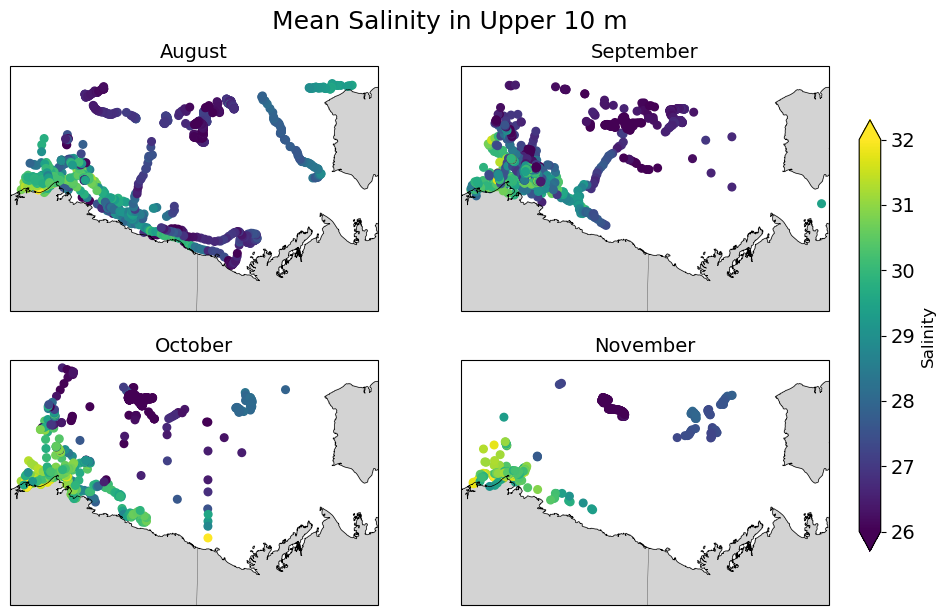

In [106]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(13, 7),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-157.5, -125, 67, 75.5], crs=ccrs.PlateCarree())

    # add isobaths
    # bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)

    # gridlines (no labels)
    # gl = ax.gridlines(draw_labels=False, dms=True,
    #                   x_inline=False, y_inline=False)

    # subset each dataset by month
    apb_m = apb_ds.where(apb_ds.time.dt.month == month, drop=True)
    ctd_m = ctd_ds.where(ctd_ds.time.dt.month == month, drop=True)
    osd_m = osd_ds.where(osd_ds.time.dt.month == month, drop=True)
    pfl_m = pfl_ds.where(pfl_ds.time.dt.month == month, drop=True)
    drb_m = drb_ds.where(drb_ds.time.dt.month == month, drop=True)

    # SCATTER PLOTS (capturing the last one for colorbar)
    sc = ax.scatter(
        apb_m.lon, apb_m.lat, s=30,
        c=apb_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        ctd_m.lon, ctd_m.lat, s=30,
        c=ctd_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        osd_m.lon, osd_m.lat, s=30,
        c=osd_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        pfl_m.lon, pfl_m.lat, s=30,
        c=pfl_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        drb_m.lon, drb_m.lat, s=30,
        c=drb_m.Salinity.sel(z=slice(0,10)).mean('z'),
        vmin=26, vmax=32, transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{month_names[month]}", fontsize=14)
    
fig.suptitle("Mean Salinity in Upper 10 m          ", fontsize=18, y=0.96)

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("Salinity", fontsize=12)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

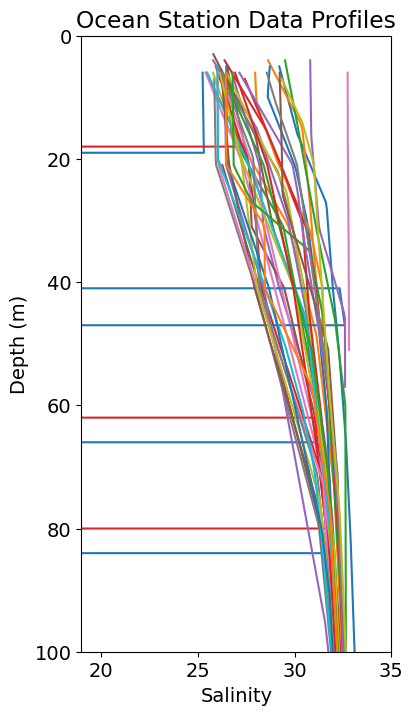

In [102]:
plt.rcParams['font.size'] = 14
osd_ds.Salinity.where(osd_ds.Salinity_WODflag==0).plot(hue='time',y='z',add_legend=False,figsize=[4,8])
plt.xlim(19,35)
plt.ylim(100,0);
plt.title('Ocean Station Data Profiles')
plt.ylabel('Depth (m)')
plt.xlabel('Salinity');

In [110]:
def compute_mld(apb_ds, rho_thresh=0.1):
    """
    Compute mixed layer depth using a 0.1 kg/m^3 density threshold.
    Uses z (m, positive downward) instead of pressure.
    
    Parameters
    ----------
    apb_ds : xarray.Dataset
        Must include:
        - Salinity(time, z)
        - Temperature(time, z)
        - z (m, positive downward)
        - Latitude(time)
        - Longitude(time)
    rho_thresh : float
        Density increase threshold (kg/m^3).
    
    Returns
    -------
    xarray.DataArray of MLD (time).
    """

    # Convert depth (m) → pressure (dbar)
    pressure = apb_ds.z  # 1 m ≈ 1 dbar

    # Broadcast latitude + longitude to match (time, z)
    lat2d = apb_ds.lat.broadcast_like(apb_ds.Salinity)
    lon2d = apb_ds.lon.broadcast_like(apb_ds.Salinity)

    # Compute Absolute Salinity and Conservative Temperature
    SA = gsw.SA_from_SP(apb_ds.Salinity, pressure, lon2d, lat2d)
    CT = gsw.CT_from_t(SA, apb_ds.Temperature, pressure)

    # Compute density (kg/m^3)
    rho = gsw.rho(SA, CT, pressure)

    mld_list = []

    # Loop profiles
    for t in apb_ds.time:
        rho_profile = rho.sel(time=t)
        depth_profile = apb_ds.z  # same for all times

        # reference density at **uppermost valid measurement**
        valid_idx = np.where(~np.isnan(rho_profile.values))[0]
        if len(valid_idx) == 0:
            mld_list.append(np.nan)
            continue

        rho0 = rho_profile.isel(z=valid_idx[0]).values

        # density anomaly relative to surface
        drho = rho_profile - rho0

        # first z where drho >= threshold
        idx = np.argmax(drho.values >= rho_thresh)

        if drho[idx] >= rho_thresh:
            mld = depth_profile.isel(z=idx).item()
        else:
            mld = np.nan  # no mixed layer depth found

        mld_list.append(mld)

    # Return as DataArray
    return xr.DataArray(
        mld_list,
        coords={'time': apb_ds.time},
        dims=['time'],
        name='MLD',
        attrs={'units': 'm', 'long_name': 'Mixed Layer Depth (0.1 kg/m^3 threshold)'}
    )

In [170]:
# ctd_mld = compute_mld(ctd_ds)
drb_mld = compute_mld(drb_ds.isel(z=slice(0,100)))
# osd_mld = compute_mld(osd_ds)
# pfl_mld = compute_mld(pfl_ds)
# apb_mld = compute_mld(apb_ds)

In [130]:
# test function and MLD threshold
tmp = ctd_ds.isel(z=slice(0,100))

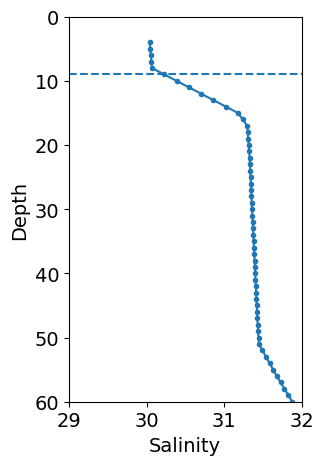

In [158]:
# 7 is good example
i=9
mld_tmp = ctd_mld.isel(time=i)

tmp.Salinity.isel(time=i).plot(add_legend=False,y='z',marker='.',figsize=[3,5])
plt.axhline(y=mld_tmp,linestyle='dashed')
plt.xlim(29,32)
plt.ylabel('Depth')
plt.title("")
plt.ylim(60,0);

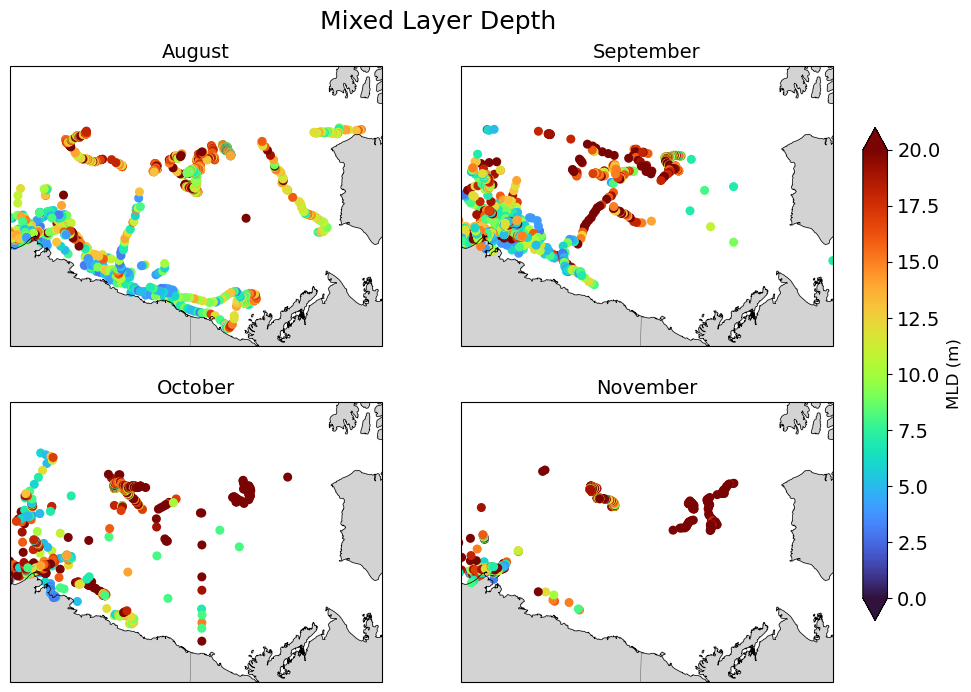

In [177]:
# months you want to plot
months = [8, 9, 10, 11]
month_names = {8: "August", 9: "September", 10: "October", 11: "November"}

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, axes = plt.subplots(2, 2, figsize=(13, 8),
                         subplot_kw={'projection': proj})

axes = axes.flatten()

# keep reference to last scatter for colorbar
sc = None

for ax, month in zip(axes, months):

    # set map extent
    ax.set_extent([-156, -125, 68, 77], crs=ccrs.PlateCarree())
    
    # add map features
    ax.add_feature(cfeature.LAND, color='lightgray')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.2)
    
    # add isobaths
    # bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())
    
    # gridlines (no labels)
    # gl = ax.gridlines(draw_labels=False, dms=True,
    #                   x_inline=False, y_inline=False)

    # subset each dataset by month
    apb_m = apb_mld.where(apb_ds.time.dt.month == month, drop=True)
    ctd_m = ctd_mld.where(ctd_ds.time.dt.month == month, drop=True)
    osd_m = osd_mld.where(osd_ds.time.dt.month == month, drop=True)
    pfl_m = pfl_mld.where(pfl_ds.time.dt.month == month, drop=True)
    drb_m = drb_mld.where(drb_ds.time.dt.month == month, drop=True)

    # SCATTER PLOTS (capturing the last one for colorbar)
    sc = ax.scatter(
        apb_m.lon, apb_m.lat, s=30,
        c=apb_m,cmap='turbo',
        vmin=0, vmax=20, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        ctd_m.lon, ctd_m.lat, s=30,
        c=ctd_m,cmap='turbo',
        vmin=0, vmax=20, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        osd_m.lon, osd_m.lat, s=30,
        c=osd_m,cmap='turbo',
        vmin=0, vmax=20, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        pfl_m.lon, pfl_m.lat, s=30,
        c=pfl_m,cmap='turbo',
        vmin=0, vmax=20, transform=ccrs.PlateCarree()
    )

    ax.scatter(
        drb_m.lon, drb_m.lat, s=30,
        c=drb_m,cmap='turbo',
        vmin=0, vmax=20, transform=ccrs.PlateCarree()
    )

    # panel title
    ax.set_title(f"{month_names[month]}", fontsize=14)

fig.suptitle("Mixed Layer Depth              ", fontsize=18, y=0.95)

cbar = fig.colorbar(sc, ax=axes, location='right', shrink=0.8, pad=0.03, extend='both')
cbar.set_label("MLD (m)", fontsize=12)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

### Plot profiles near Mackenzie River mouth

In [301]:
def compute_mld(ds, rho_thresh=0.03, lon=-137, lat=71):
    """
    Compute mixed layer depth (MLD) from a single vertical profile and 
    return both the MLD value and the computed density profile.

    Parameters
    ----------
    ds : xarray.Dataset
        Must contain 1D variables:
        - ds.Salinity (PSU)
        - ds.Temperature (°C, in-situ)
        - ds.z (depth, meters, positive downward)
    rho_thresh : float
        Density difference threshold (kg/m^3). Default = 0.03.
    lon, lat : float
        Geographic coordinates for SA_from_SP.

    Returns
    -------
    mld : float
        Mixed layer depth in meters. Returns NaN if MLD cannot be computed.
    rho : xarray.DataArray
        Density profile (kg/m^3), same shape and coords as ds.z.
    """

    # depth (m) approximates pressure (dbar)
    pressure = ds.z.values

    # Absolute Salinity & Conservative Temperature
    SA = gsw.SA_from_SP(ds.Salinity, pressure, lon, lat)
    CT = gsw.CT_from_t(SA, ds.Temperature, pressure)

    # Density (kg/m^3)
    rho = gsw.rho(SA, CT, pressure)

    # First valid density point = "surface"
    valid_idx = np.where(~np.isnan(rho))[0]
    if len(valid_idx) == 0:
        return np.nan, rho

    surface_idx = valid_idx[0]
    rho0 = rho[surface_idx]

    # Density anomaly
    drho = rho - rho0

    # Depth where density increases by threshold
    meets_threshold = drho.values >= rho_thresh

    if not np.any(meets_threshold):
        mld = np.nan
    else:
        idx = np.argmax(meets_threshold)
        mld = pressure[idx].item()

    return mld, rho
    # return meets_threshold

In [9]:
pinniped_mack = apb_ds.where(apb_ds.lon>-140,drop=True).where(apb_ds.lat<71,drop=True)

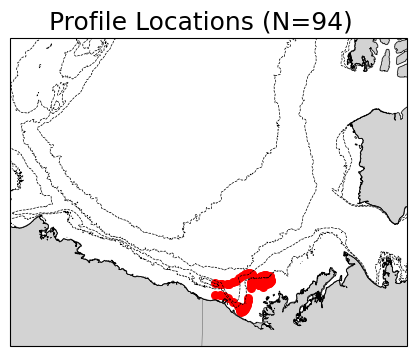

In [247]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-156, -125, 67.5, 77], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_mack.lon, pinniped_mack.lat, s=30,
    c='r',transform=ccrs.PlateCarree()
)

fig.suptitle("Profile Locations (N=94)", fontsize=18, y=0.95)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

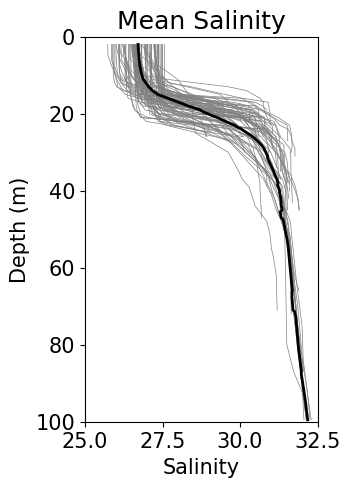

In [353]:
plt.rcParams['font.size'] = 15
pinniped_mack.Salinity.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_mack.Salinity.mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(25,32.5)
plt.title('Mean Salinity')
plt.ylabel('Depth (m)');

In [273]:
pinniped_mack_avg = pinniped_mack.mean('time')

In [279]:
pinniped_mack_avg

<xarray.Dataset> Size: 5kB
Dimensions:      (z: 200)
Coordinates:
  * z            (z) float64 2kB 0.0 0.5 1.0 1.5 2.0 ... 98.0 98.5 99.0 99.5
Data variables:
    Temperature  (z) float64 2kB dask.array<chunksize=(200,), meta=np.ndarray>
    Salinity     (z) float64 2kB dask.array<chunksize=(200,), meta=np.ndarray>

In [315]:
mack_avg_mld_0pt1, pinniped_mack_avg_rho = compute_mld(pinniped_mack_avg, rho_thresh=0.1)
mack_avg_mld_0pt3, pinniped_mack_avg_rho = compute_mld(pinniped_mack_avg, rho_thresh=0.3)

In [357]:
print(mack_avg_mld_0pt1)
print(mack_avg_mld_0pt3)

8.5
12.5


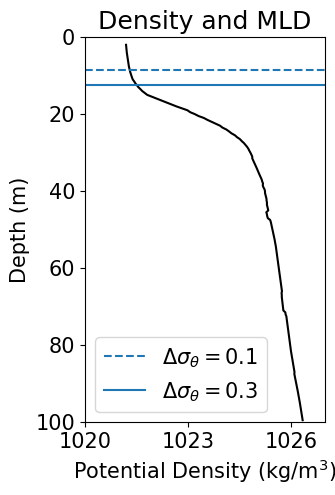

In [355]:
plt.rcParams['font.size'] = 15
pinniped_mack_avg_rho.plot(y='z',c='k',figsize=[3.1,5])
plt.axhline(y=mack_avg_mld_0pt1,linestyle='dashed',label = r'$\Delta \sigma_\theta = 0.1$')
plt.axhline(y=mack_avg_mld_0pt3,linestyle='solid',label = r'$\Delta \sigma_\theta = 0.3$')
plt.legend()
plt.ylim(100,0)
plt.xlim(1020,1027)
plt.xticks([1020,1023,1026])
plt.title("Density and MLD")
plt.xlabel('Potential Density (kg/m$^3$)');
plt.ylabel('Depth (m)');

In [13]:
pinn_aug19 = apb_ds.sel(time='2019-08')

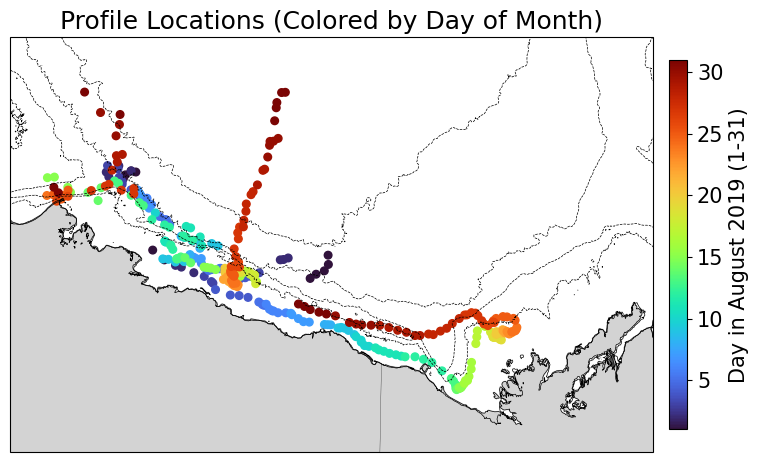

In [411]:
# extract day of month (1–31)
days = pinn_aug19.time.dt.day

# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(10, 6),
                       subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-156, -130, 68, 74], crs=ccrs.PlateCarree())

# map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# isobaths
bathy_beaufort.plot.contour(
    ax=ax,
    levels=[0, -50, -100, -1000, -3000],
    colors='k',
    linewidths=0.5,
    transform=ccrs.PlateCarree()
)

# SCATTER PLOTS — colored by day of month
sc = ax.scatter(
    pinn_aug19.lon,
    pinn_aug19.lat,
    s=30,
    c=days,
    cmap='turbo',
    vmin=1,
    vmax=31,
    transform=ccrs.PlateCarree()
)

# colorbar
cbar = fig.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label("Day in August 2019 (1-31)")

plt.title("Profile Locations (Colored by Day of Month)", fontsize=18)

plt.show()

In [15]:
pinniped_west = pinn_aug19.where(pinn_aug19.lon>-160,drop=True).where(pinn_aug19.lon<-150,drop=True).where(pinn_aug19.lat<72,drop=True)

In [21]:
pinniped_west

<xarray.Dataset> Size: 269kB
Dimensions:      (time: 83, z: 200)
Coordinates:
  * time         (time) datetime64[ns] 664B 2019-08-01T08:00:00.000858112 ......
  * z            (z) float64 2kB 0.0 0.5 1.0 1.5 2.0 ... 98.0 98.5 99.0 99.5
    lat          (time) float32 332B 71.94 70.98 70.87 ... 71.83 71.53 71.47
    lon          (time) float32 332B -153.9 -151.8 -151.2 ... -157.0 -156.8
Data variables:
    Temperature  (time, z) float64 133kB dask.array<chunksize=(1, 200), meta=np.ndarray>
    Salinity     (time, z) float64 133kB dask.array<chunksize=(1, 200), meta=np.ndarray>
Attributes: (12/37)
    flag_definitions:              WODfd
    institution:                   National Oceanographic Data Center(NODC), ...
    source:                        World Ocean Database
    references:                    World Ocean Database 2013. URL:http://data...
    title:                         World Ocean Database - Unique Cast 017303083
    summary:                       Data for single cast from the World Ocean ...
    ...                            ...
    history:                       
    license:                       
    standard_name_vocabulary:      CF-1.6
    featureType:                   Profile
    cdm_data_type:                 Profile
    Conventions:                   CF-1.6

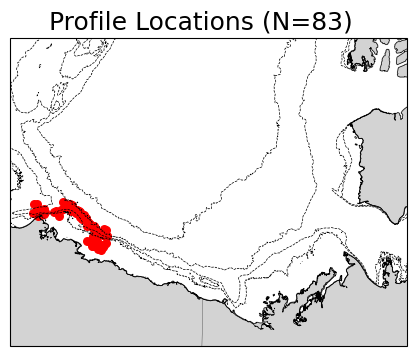

In [19]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-156, -125, 67.5, 77], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_west.lon, pinniped_west.lat, s=30,
    c='r',transform=ccrs.PlateCarree()
)

fig.suptitle("Profile Locations (N=83)", fontsize=18, y=0.95)

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

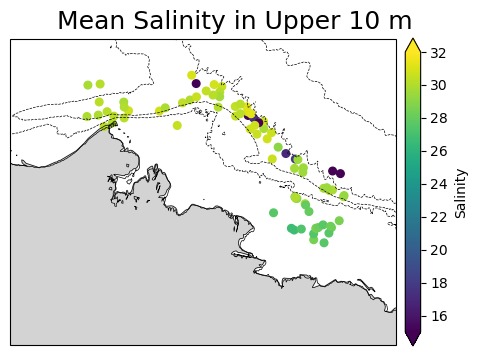

In [27]:
# define projection centered at 150°W
proj = ccrs.NorthPolarStereo(central_longitude=-140)

fig, ax = plt.subplots(1, 1, figsize=(6, 4),
                         subplot_kw={'projection': proj})

# set map extent
ax.set_extent([-158, -149, 70, 72], crs=ccrs.PlateCarree())

# add map features
ax.add_feature(cfeature.LAND, color='lightgray')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2)

# add isobaths
bathy_beaufort.plot.contour(ax=ax,levels=[0,-50,-100,-1000,-3000],colors='k',linewidths=0.5,transform=ccrs.PlateCarree())

# SCATTER PLOTS (capturing the last one for colorbar)
sc = ax.scatter(
    pinniped_west.lon, pinniped_west.lat, s=30,
    c=pinniped_west.Salinity.sel(z=slice(0,10)).mean('z'),vmin=15,vmax=32,transform=ccrs.PlateCarree()
)

fig.suptitle("Mean Salinity in Upper 10 m", fontsize=18, y=0.95)

# colorbar
cbar = fig.colorbar(sc, ax=ax, extend='both', pad=0.02)
cbar.set_label("Salinity")

# spacing
# plt.tight_layout(rect=[0, 0, 0.93, 0.95])
plt.show()

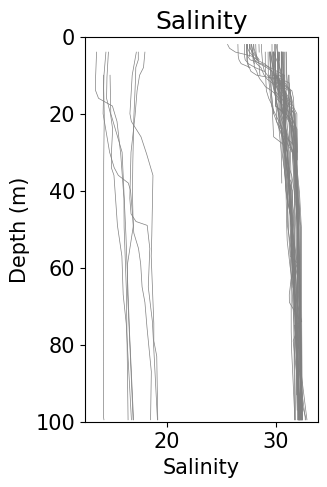

In [455]:
plt.rcParams['font.size'] = 15
pinniped_west.Salinity.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
# pinniped_west.Salinity.mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
# plt.xlim(25,32.5)
plt.title('Salinity')
plt.ylabel('Depth (m)');

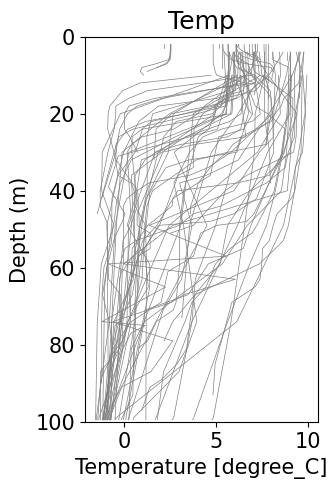

In [39]:
plt.rcParams['font.size'] = 15
pinniped_west.Temperature.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
# pinniped_west.Salinity.mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
# plt.xlim(25,32.5)
plt.title('Temp')
plt.ylabel('Depth (m)');

In [29]:
pinniped_west_filter = pinniped_west.sel(time=(pinniped_west.Salinity.isel(z=20)>20).values)

In [31]:
pinniped_west_filter

<xarray.Dataset> Size: 201kB
Dimensions:      (time: 62, z: 200)
Coordinates:
  * time         (time) datetime64[ns] 496B 2019-08-01T08:00:00.000858112 ......
  * z            (z) float64 2kB 0.0 0.5 1.0 1.5 2.0 ... 98.0 98.5 99.0 99.5
    lat          (time) float32 248B 71.94 70.82 71.97 ... 71.83 71.53 71.47
    lon          (time) float32 248B -153.9 -150.6 -154.8 ... -157.0 -156.8
Data variables:
    Temperature  (time, z) float64 99kB dask.array<chunksize=(1, 200), meta=np.ndarray>
    Salinity     (time, z) float64 99kB dask.array<chunksize=(1, 200), meta=np.ndarray>
Attributes: (12/37)
    flag_definitions:              WODfd
    institution:                   National Oceanographic Data Center(NODC), ...
    source:                        World Ocean Database
    references:                    World Ocean Database 2013. URL:http://data...
    title:                         World Ocean Database - Unique Cast 017303083
    summary:                       Data for single cast from the World Ocean ...
    ...                            ...
    history:                       
    license:                       
    standard_name_vocabulary:      CF-1.6
    featureType:                   Profile
    cdm_data_type:                 Profile
    Conventions:                   CF-1.6

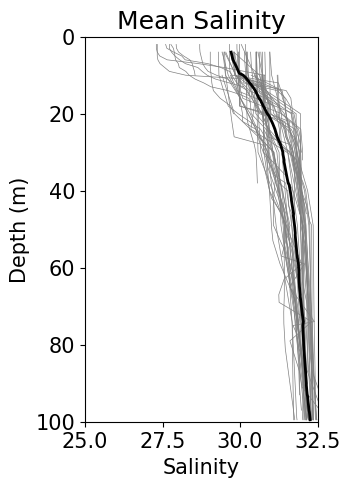

In [487]:
plt.rcParams['font.size'] = 15
pinniped_west_filter.Salinity.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_west_filter.Salinity.isel(z=slice(8,200)).mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
plt.xlim(25,32.5)
plt.title('Mean Salinity')
plt.ylabel('Depth (m)');

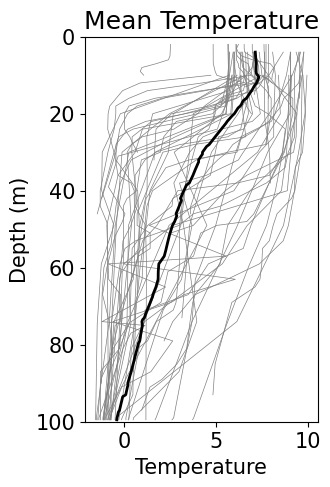

In [37]:
plt.rcParams['font.size'] = 15
pinniped_west_filter.Temperature.plot(hue='time',y='z',c='gray',linewidth=0.5,\
                            add_legend=False,label='All Profiles',figsize=[3,5])
pinniped_west_filter.Temperature.isel(z=slice(8,200)).mean('time').plot(y='z',c='k',linewidth=2,label='Mean')
plt.ylim(100,0)
# plt.xlim(25,32.5)
plt.title('Mean Temperature')
plt.ylabel('Depth (m)');

In [489]:
pinniped_west_avg = pinniped_west_filter.isel(z=slice(8,200)).mean('time')

In [495]:
west_avg_mld_0pt1, pinniped_west_avg_rho = compute_mld(pinniped_west_avg, rho_thresh=0.1)
west_avg_mld_0pt3, pinniped_west_avg_rho = compute_mld(pinniped_west_avg, rho_thresh=0.3)

In [497]:
print(west_avg_mld_0pt1)
print(west_avg_mld_0pt3)

7.0
10.0


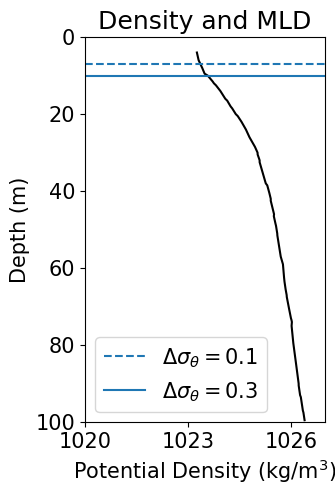

In [501]:
plt.rcParams['font.size'] = 15
pinniped_west_avg_rho.plot(y='z',c='k',figsize=[3.1,5])
plt.axhline(y=west_avg_mld_0pt1,linestyle='dashed',label = r'$\Delta \sigma_\theta = 0.1$')
plt.axhline(y=west_avg_mld_0pt3,linestyle='solid',label = r'$\Delta \sigma_\theta = 0.3$')
plt.legend()
plt.ylim(100,0)
plt.xlim(1020,1027)
plt.xticks([1020,1023,1026])
plt.title("Density and MLD")
plt.xlabel('Potential Density (kg/m$^3$)');
plt.ylabel('Depth (m)');